# Polar MHW Heat Budget: Circumpolar Analysis

Extends the single-box (notebook 01) and 6-box transect (notebook 02) analyses to the full
Southern Ocean south of 60°S, using **10×10 grid-cell boxes** (2.5°×2.5° each at 0.25° resolution).

For every valid ocean box (≥75% ocean cells):
1. Detect MHW events using Hobday et al. (2016) threshold exceedance.
2. Separate onset (start→peak) from decline (peak→end).
3. Compute mean mixed-layer heat budget anomalies for each phase.
4. Save composites to NetCDF for spatial mapping.

The ACCESS-OM2 grid seam at ~80°E is handled with a two-slice concatenation.  
Pre-compute is split into latitude bands to keep Dask graphs tractable.

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle
import pandas as pd
import cmocean.cm as cmo
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import pickle

%matplotlib inline

In [2]:
from dask.distributed import Client

# processes=True + threads_per_worker=1 avoids netCDF4/HDF5 thread-safety races
# when many workers read chunks from the same open_mfdataset files concurrently.
client = Client(processes=True, threads_per_worker=1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 28
Total threads: 28,Total memory: 125.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:36071,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:40281,Total threads: 1
Dashboard: /proxy/46633/status,Memory: 4.47 GiB
Nanny: tcp://127.0.0.1:39937,


## 1. Configuration

In [ ]:
def map_lon_to_ds(lon_e, lon_coord_min=-280.0, lon_coord_max=80.0):
    """Map standard longitudes to the ACCESS-OM2 grid convention."""
    lonmin, lonmax = lon_coord_min, lon_coord_max
    if 0.0 <= lonmin and lonmax <= 360.0:
        return lon_e % 360.0
    if -180.0 <= lonmin and lonmax <= 180.0:
        return ((lon_e + 180.0) % 360.0) - 180.0
    if lonmax <= 100.0 and lonmin < -180.0:  # ACCESS-style (-280 to 80)
        return lon_e if lon_e <= lonmax else lon_e - 360.0
    return lon_e


# ── Domain ────────────────────────────────────────────────────────────────────
LAT_MIN      = -80.0   # southernmost latitude
LAT_MAX      = -60.0   # 60°S study boundary
BOX_DEG      =   2.5   # box size in degrees (10 grid cells at 0.25°)
MIN_OCN_FRAC =   0.75  # minimum ocean cell fraction to include a box

# Set TEST_MODE = True to run only ~6 boxes overlapping the NB02 Drake Passage
# transect — useful for validating results against notebook 02 before a full PBS run.
TEST_MODE = False

# ── Data ──────────────────────────────────────────────────────────────────────
base         = '/g/data/av17/access-nri/OM2/025deg_jra55_iaf_cycle6_online_mlt/'
START_OUTPUT = 357     # 2010
END_OUTPUT   = 366     # 2019
outputs      = list(range(START_OUTPUT, END_OUTPUT + 1))
OUTPUT_DIR   = '/scratch/m35/nm5072/Polar_MHWs/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── MHW detection ─────────────────────────────────────────────────────────────
MIN_DUR = 5
MAX_GAP = 2

# ── Dask / I/O ────────────────────────────────────────────────────────────────
chunks2D    = {'time': 365, 'yt_ocean': 216, 'xt_ocean': 240}
SEC_PER_DAY = 86400.0

# ── Budget terms ──────────────────────────────────────────────────────────────
TERM_MAP = {
    'MLT tendency'   : 'mlt_tendency',
    'Surface Flux'   : 'surf_to_ML',
    'Advection'      : 'advection',
    'Vertical mixing': 'vert_mixing',
    'Entrainment'    : 'entrainment',
}
BUDGET_TERMS  = list(TERM_MAP.keys())
SEASONS       = ['DJF', 'MAM', 'JJA', 'SON']
SEASON_COLORS = {'DJF': 'tab:red', 'MAM': 'tab:orange',
                 'JJA': 'tab:blue', 'SON': 'tab:green'}

## 2. Generate circumpolar boxes

In [4]:
def generate_circumpolar_boxes(lat_min, lat_max, box_deg):
    """
    Tile the full circumpolar domain with boxes of size box_deg × box_deg.

    Boxes are defined in geographic longitude (0–360°) and converted to the
    ACCESS-OM2 xt_ocean convention with map_lon_to_ds.  The one box that
    straddles the grid seam at ~80°E (where xt_ocean jumps from ~80 to ~-280)
    is flagged; _box_slice handles it with a two-part concatenation.
    """
    boxes = []
    lat = lat_min
    while round(lat, 6) < lat_max:
        lon_geo = 0.0
        while round(lon_geo, 6) < 360.0:
            lo_max  = lon_geo + box_deg
            lds_min = map_lon_to_ds(lon_geo)
            lds_max = map_lon_to_ds(lo_max)
            boxes.append({
                'lon_geo_min': lon_geo,
                'lon_geo_max': lo_max,
                'lon_min_ds' : lds_min,
                'lon_max_ds' : lds_max,
                'lat_min'    : lat,
                'lat_max'    : lat + box_deg,
                'lon_center' : lon_geo + box_deg / 2,
                'lat_center' : lat    + box_deg / 2,
                'seam'       : lds_min > lds_max,  # straddles the -280/80 seam
                'ocean_frac' : np.nan,
            })
            lon_geo = round(lon_geo + box_deg, 6)
        lat = round(lat + box_deg, 6)
    return boxes


def _box_slice(da, box):
    """
    Slice a DataArray or Dataset to a box, handling the ACCESS-OM2 seam at ~80°E.

    For the one seam-straddling box, the two non-contiguous parts of the grid
    are concatenated along xt_ocean.  Empty parts (if 80° is not an exact grid
    point) are dropped before concat.
    """
    lat_kw = dict(yt_ocean=slice(box['lat_min'], box['lat_max']))
    if box['seam']:
        p1 = da.sel(xt_ocean=slice(box['lon_min_ds'], 80.0), **lat_kw)
        p2 = da.sel(xt_ocean=slice(-280.0, box['lon_max_ds']), **lat_kw)
        parts = [p for p in (p1, p2) if p.sizes.get('xt_ocean', 0) > 0]
        return xr.concat(parts, dim='xt_ocean') if len(parts) > 1 else parts[0]
    return da.sel(
        xt_ocean=slice(box['lon_min_ds'], box['lon_max_ds']), **lat_kw
    )


all_boxes = generate_circumpolar_boxes(LAT_MIN, LAT_MAX, BOX_DEG)
n_lat = int((LAT_MAX - LAT_MIN) / BOX_DEG)
n_lon = int(360.0 / BOX_DEG)
print(f"Candidate boxes: {len(all_boxes)}  ({n_lon} lon × {n_lat} lat bands)")
print(f"Seam-straddling boxes: {sum(b['seam'] for b in all_boxes)}")

Candidate boxes: 288  (72 lon × 4 lat bands)
Seam-straddling boxes: 4


## 3. Land mask and box filtering

Ocean fraction is derived from the fraction of non-NaN cells in `temp_in_mld`
averaged over the first calendar month (January 2010 — austral summer, minimal sea ice).
Boxes with ocean fraction ≥75% are retained.

In [5]:
mask_file  = base + f'output{START_OUTPUT:03d}/ocean/ocean_daily.nc'
mask_month = (
    xr.open_dataset(mask_file, decode_times=False)
    .isel(time=slice(0, 31))
    .sel(yt_ocean=slice(LAT_MIN, LAT_MAX))
)
ocean_full = (mask_month['temp_in_mld'] / 1035).notnull().mean('time').compute()
print(f"Mask computed from {mask_file}")

for box in all_boxes:
    sub = _box_slice(ocean_full, box)
    box['ocean_frac'] = float(sub.mean()) if sub.size > 0 else 0.0

valid_boxes = [b for b in all_boxes if b['ocean_frac'] >= MIN_OCN_FRAC]

if TEST_MODE:
    # Restrict to Drake Passage area (overlaps NB02) for quick validation
    valid_boxes = [
        b for b in valid_boxes
        if 270.0 <= b['lon_center'] <= 295.0 and b['lat_center'] >= -70.0
    ]
    print(f"TEST_MODE: {len(valid_boxes)} boxes (Drake Passage subset)")

box_ids = [
    f"lon{b['lon_center']:.1f}_lat{b['lat_center']:.1f}" for b in valid_boxes
]

print(f"Valid ocean boxes (≥{int(MIN_OCN_FRAC*100)}%): {len(valid_boxes)} / {len(all_boxes)}")
print("\nValid boxes per latitude band:")
for lat_lo in np.arange(LAT_MIN, LAT_MAX, BOX_DEG):
    lat_hi = lat_lo + BOX_DEG
    lat_c  = lat_lo + BOX_DEG / 2
    band   = [b for b in valid_boxes if abs(b['lat_center'] - lat_c) < 0.01]
    print(f"  {abs(lat_lo):.0f}°S–{abs(lat_hi):.0f}°S: {len(band)} boxes")

Mask computed from /g/data/av17/access-nri/OM2/025deg_jra55_iaf_cycle6_online_mlt/output357/ocean/ocean_daily.nc
Valid ocean boxes (≥75%): 146 / 288

Valid boxes per latitude band:
  80°S–75°S: 0 boxes
  75°S–70°S: 25 boxes
  70°S–65°S: 49 boxes
  65°S–60°S: 72 boxes


## 4. Context map

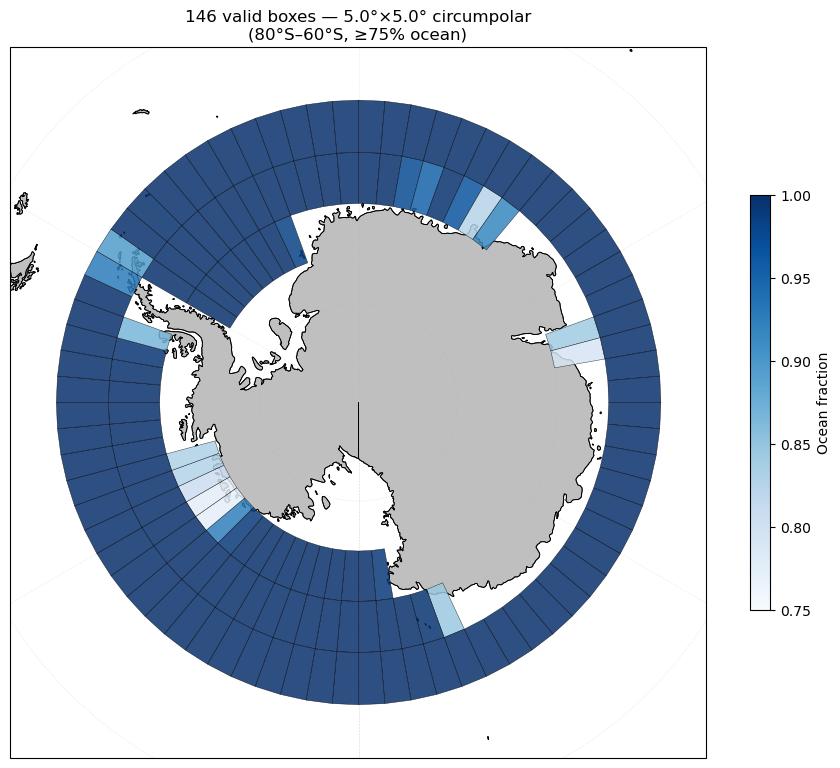

In [6]:
fig = plt.figure(figsize=(9, 8))
ax  = plt.axes(projection=ccrs.SouthPolarStereo())
ax.set_extent([-180, 180, -90, -55], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='0.75', edgecolor='k', linewidth=0.5, zorder=2)
ax.coastlines(linewidth=0.7, zorder=3)
ax.gridlines(draw_labels=False, linestyle=':', linewidth=0.4, alpha=0.5)

cmap_frac = plt.cm.Blues
norm_frac  = mcolors.Normalize(MIN_OCN_FRAC, 1.0)

for box in valid_boxes:
    lon0  = box['lon_geo_min'] if box['lon_geo_min'] <= 180 else box['lon_geo_min'] - 360
    color = cmap_frac(norm_frac(box['ocean_frac']))
    ax.add_patch(Rectangle(
        (lon0, box['lat_min']), BOX_DEG, BOX_DEG,
        facecolor=color, edgecolor='k', linewidth=0.3,
        alpha=0.85, transform=ccrs.PlateCarree(), zorder=4,
    ))

sm = plt.cm.ScalarMappable(cmap=cmap_frac, norm=norm_frac)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Ocean fraction', shrink=0.55, pad=0.05)
ax.set_title(
    f'{len(valid_boxes)} valid boxes — {BOX_DEG}°×{BOX_DEG}° circumpolar\n'
    f'({abs(LAT_MIN):.0f}°S–{abs(LAT_MAX):.0f}°S, ≥{int(MIN_OCN_FRAC*100)}% ocean)',
    fontsize=12,
)
plt.tight_layout()

## 5. Running as a PBS batch job on Gadi

This notebook processes ~150 boxes over 10 years of daily data.  The largest cost is
the pre-compute step (section 8); scale the walltime from how long the equivalent
step took in notebook 02 for 6 boxes.

Submit as a headless PBS job so it survives terminal disconnection:

```bash
cat > run_circumpolar.pbs << 'EOF'
#!/bin/bash
#PBS -N polar_mhw_circ
#PBS -q normal
#PBS -l walltime=8:00:00        # adjust based on NB02 runtime × ~25
#PBS -l mem=96GB
#PBS -l ncpus=8
#PBS -l storage=gdata/av17+gdata/hh5
#PBS -j oe

module use /g/data/hh5/public/modules
module load conda/analysis3

cd $PBS_O_WORKDIR
jupyter nbconvert --to notebook --execute --inplace \\
    --ExecutePreprocessor.timeout=28800 \\
    notebooks/03_polar_mhw_circumpolar.ipynb
EOF
qsub run_circumpolar.pbs
```

**Before submitting:** run with `TEST_MODE = True` (section 1) to verify the
Drake Passage boxes match notebook 02 results, then flip back to `False`.

## 6. Load circumpolar data (lazy)

In [7]:
mlt_files = [base + f'output{o:03d}/ocean/ocean_daily.nc' for o in outputs]

ds_wide = xr.open_mfdataset(
    mlt_files,
    decode_times=True, chunks=chunks2D,
    combine='nested', concat_dim='time',
    data_vars=['temp_in_mld', 'mld'],
    parallel=True, decode_timedelta=False,
).sel(yt_ocean=slice(LAT_MIN, LAT_MAX))

temp_wide = ds_wide['temp_in_mld'] / 1035
print(f"MLT loaded (lazy): {dict(ds_wide.dims)}")

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.06/lib/python3.12/site-packages/dask/_task_spec.py:767: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 365. This could degrade performance. Instead, consider rechunking after loading.
  return self.func(*new_argspec, **kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.06/lib/python3.12/site-packages/dask/_task_spec.py:767: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 365. This could degrade performance. Instead, consider rechunking after loading.
  return self.func(*new_argspec, **kwargs)


MLT loaded (lazy): {'time': 3652, 'yt_ocean': 185, 'xt_ocean': 1440, 'yu_ocean': 1080, 'xu_ocean': 1440, 'nv': 2}


/jobfs/174176012.gadi-pbs/ipykernel_2736137/2132372783.py:12: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"MLT loaded (lazy): {dict(ds_wide.dims)}")


In [8]:
budget_files = [
    base + 'post_processed_diags/mlt_budget_online_stavg/'
    f'mlt_budget_stavg_daily_online_output{o:03d}.nc'
    for o in outputs
]
vars_raw = [
    'mlt_tendency', 'advection', 'vert_mixing',
    'entrainment', 'surface_flux', 'sw_pen', 'residual',
]

budget_wide = xr.open_mfdataset(
    budget_files,
    decode_times=True, chunks=chunks2D,
    combine='nested', concat_dim='time',
    parallel=True, decode_timedelta=False,
).sel(yt_ocean=slice(LAT_MIN, LAT_MAX))[vars_raw]
budget_wide['surf_to_ML'] = budget_wide['surface_flux'] + budget_wide['sw_pen']

clim_wide   = xr.open_dataset(
    base + 'post_processed_diags/om2_025_MLT_clim.nc'
).sel(yt_ocean=slice(LAT_MIN, LAT_MAX))
thresh_wide = xr.open_dataset(
    base + 'post_processed_diags/om2_025_MLT_thresh.nc'
).sel(yt_ocean=slice(LAT_MIN, LAT_MAX))

budget_clim_wide = xr.open_dataset(
    base + 'post_processed_diags/mlt_budget_online_stavg/'
           'mlt_budget_stavg_daily_online_output336-365_monthly_mean.ncea.nc'
).sel(yt_ocean=slice(LAT_MIN, LAT_MAX))
budget_clim_wide['surf_to_ML'] = (
    budget_clim_wide['surface_flux'] + budget_clim_wide['sw_pen']
)

print(f"Budget loaded (lazy): {dict(budget_wide.dims)}")
print("Climatology files opened.")

Budget loaded (lazy): {'time': 3652, 'yt_ocean': 185, 'xt_ocean': 1440}
Climatology files opened.


/jobfs/174176012.gadi-pbs/ipykernel_2736137/3973974521.py:34: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Budget loaded (lazy): {dict(budget_wide.dims)}")


## 7. Helper functions

In [9]:
def _weights(da):
    return np.cos(np.deg2rad(da['yt_ocean']))


def _box_mean(da, box):
    sub = _box_slice(da, box)
    return sub.weighted(_weights(sub)).mean(('xt_ocean', 'yt_ocean'))


def detect_mhw_events(temp_da, thresh_da, min_dur=5, max_gap=2):
    """Hobday et al. (2016) event detection. Returns list of dicts: t_start, t_peak, t_end."""
    t      = pd.to_datetime(temp_da.time.values)
    y_temp = temp_da.values
    y_thr  = thresh_da.values
    valid  = np.isfinite(y_temp) & np.isfinite(y_thr)

    if valid.sum() < min_dur:
        return []

    exceed = pd.Series((y_temp[valid] > y_thr[valid]).astype(int), index=t[valid])

    runs        = (exceed.diff(1).ne(0)).cumsum()
    run_lengths = exceed.groupby(runs).transform('size')
    short_false = (exceed == 0) & (run_lengths <= max_gap)
    merged      = exceed.copy()
    merged[short_false] = 1

    runs2     = (merged.diff(1).ne(0)).cumsum()
    lens2     = merged.groupby(runs2).transform('size')
    long_true = (merged == 1) & (lens2 >= min_dur)

    anom = pd.Series(y_temp[valid] - y_thr[valid], index=t[valid])
    arr, idx = long_true.to_numpy(), long_true.index.to_numpy()
    events, start_i = [], None
    for i in range(len(arr)):
        if arr[i] and start_i is None:
            start_i = i
        if start_i is not None and (i == len(arr) - 1 or not arr[i + 1]):
            seg    = anom.iloc[start_i:i + 1]
            t_peak = seg.idxmax()
            events.append({'t_start': idx[start_i], 't_peak': t_peak, 't_end': idx[i]})
            start_i = None
    return events


def get_season(timestamp):
    """Austral season from month of timestamp."""
    m = pd.Timestamp(timestamp).month
    if m in (12, 1, 2): return 'DJF'
    if m in (3, 4, 5):  return 'MAM'
    if m in (6, 7, 8):  return 'JJA'
    return 'SON'


def build_budget_clim_daily(budget_clim_box, budget_time):
    """Interpolate monthly budget climatology to daily and apply 31-day smoothing."""
    clim_by_month = (
        budget_clim_box.groupby('time.month').mean('time')
        .assign_coords(month=np.arange(1, 13))
    )
    dec         = clim_by_month.sel(month=12).expand_dims(month=[0])
    jan         = clim_by_month.sel(month=1).expand_dims(month=[13])
    clim_padded = xr.concat([dec, clim_by_month, jan], dim='month')
    clim_smooth = clim_padded.interp(month=np.linspace(1, 12, 365))

    doys = (budget_time.dt.dayofyear - 1) % 365
    clim_daily = xr.Dataset({
        name: clim_smooth[name].isel(month=doys).assign_coords(time=budget_time)
        for name in BUDGET_TERMS
    })
    return clim_daily.rolling(time=31, center=True, min_periods=1).mean()


print("Helper functions defined.")

Helper functions defined.


## 8. Pre-compute all box means — by latitude band

Data are loaded lazily for the full circumpolar strip.  Computing all ~150 boxes in a
single Dask graph can be slow to optimise; processing one latitude band at a time
(~72 boxes per band) keeps each graph tractable.  Results are accumulated in plain
dicts so the loop in section 9 can access them by `box_id`.

In [10]:
# Organise valid boxes into latitude bands
lat_band_centers = [LAT_MIN + (i + 0.5) * BOX_DEG for i in range(n_lat)]

lat_bands = {}
for lat_c in lat_band_centers:
    lat_bands[lat_c] = [
        (bid, box) for bid, box in zip(box_ids, valid_boxes)
        if abs(box['lat_center'] - lat_c) < 0.01
    ]

# Per-band checkpointing: a lat band's results are pickled to disk once computed,
# so a crash (e.g. a transient Gadi I/O error) only loses the in-progress band —
# re-running the cell resumes from the last completed band instead of starting over.
CHECKPOINT_DIR = f'{OUTPUT_DIR}/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)


def checkpoint_path(lat_c):
    return f'{CHECKPOINT_DIR}/lat_band_{lat_c:.1f}.pkl'


mlt_all    = {}
clim_all   = {}
thresh_all = {}
budget_all = {}
bclim_all  = {}

for lat_c, band in lat_bands.items():
    if not band:
        continue

    ckpt = checkpoint_path(lat_c)
    if os.path.exists(ckpt):
        print(f"\n── Lat band {lat_c:.1f}°  ({len(band)} boxes) — loaded from checkpoint ──")
        with open(ckpt, 'rb') as fh:
            saved = pickle.load(fh)
        mlt_all.update(saved['mlt'])
        clim_all.update(saved['clim'])
        thresh_all.update(saved['thresh'])
        budget_all.update(saved['budget'])
        bclim_all.update(saved['bclim'])
        continue

    print(f"\n── Lat band {lat_c:.1f}°  ({len(band)} boxes) ──────────────")

    # MLT, climatology, threshold
    mlt_lazy    = {bid: _box_mean(temp_wide,        box) for bid, box in band}
    clim_lazy   = {bid: _box_mean(clim_wide.temp,   box) for bid, box in band}
    thresh_lazy = {bid: _box_mean(thresh_wide.temp, box) for bid, box in band}
    print("  Computing MLT / clim / threshold ...")
    mlt_band    = dict(xr.Dataset(mlt_lazy).compute())
    clim_band   = dict(xr.Dataset(clim_lazy).compute())
    thresh_band = dict(xr.Dataset(thresh_lazy).compute())

    # Budget time series
    budget_lazy = {}
    for bid, box in band:
        sub = _box_slice(budget_wide, box)
        w   = _weights(sub)
        for term, raw in TERM_MAP.items():
            budget_lazy[f"{bid}__{term}"] = (
                sub[raw].weighted(w).mean(('yt_ocean', 'xt_ocean')) * SEC_PER_DAY
            )
    print("  Computing budget time series ...")
    budget_band = dict(xr.Dataset(budget_lazy).compute())

    # Budget climatology (monthly means — cheap)
    bclim_lazy = {}
    for bid, box in band:
        bc = _box_slice(budget_clim_wide, box)
        w  = _weights(bc)
        for term, raw in TERM_MAP.items():
            bclim_lazy[f"{bid}__{term}"] = (
                bc[raw].weighted(w).mean(('yt_ocean', 'xt_ocean')) * SEC_PER_DAY
            )
    print("  Computing budget climatology ...")
    bclim_band = dict(xr.Dataset(bclim_lazy).compute())

    with open(ckpt, 'wb') as fh:
        pickle.dump({
            'mlt': mlt_band, 'clim': clim_band, 'thresh': thresh_band,
            'budget': budget_band, 'bclim': bclim_band,
        }, fh)

    mlt_all.update(mlt_band)
    clim_all.update(clim_band)
    thresh_all.update(thresh_band)
    budget_all.update(budget_band)
    bclim_all.update(bclim_band)

print("\nAll bands done — data in memory.")


── Lat band -72.5°  (25 boxes) ──────────────
  Computing MLT / clim / threshold ...
  Computing budget time series ...
  Computing budget climatology ...

── Lat band -67.5°  (49 boxes) ──────────────
  Computing MLT / clim / threshold ...
  Computing budget time series ...
  Computing budget climatology ...

── Lat band -62.5°  (72 boxes) ──────────────
  Computing MLT / clim / threshold ...
  Computing budget time series ...
  Computing budget climatology ...

All bands done — data in memory.


## 9. Loop over boxes — MHW detection and budget decomposition

In [11]:
all_events = {}
all_df     = {}

for k, (bid, box) in enumerate(zip(box_ids, valid_boxes)):
    if k % 20 == 0:
        print(f"[{k:3d}/{len(valid_boxes)}] "
              f"lon={box['lon_center']:6.1f}°  lat={box['lat_center']:.1f}°")

    temp_vals   = mlt_all[bid]
    clim_mean   = clim_all[bid]
    thresh_mean = thresh_all[bid]

    doy_all        = temp_vals.time.dt.dayofyear.clip(max=365)
    clim_on_time   = clim_mean.sel(dayofyear=doy_all).assign_coords(time=temp_vals.time)
    thresh_on_time = thresh_mean.sel(dayofyear=doy_all).assign_coords(time=temp_vals.time)

    events = detect_mhw_events(temp_vals, thresh_on_time, MIN_DUR, MAX_GAP)
    all_events[bid] = events

    if not events:
        all_df[bid] = pd.DataFrame()
        continue

    budget_series = xr.Dataset(
        {term: budget_all[f"{bid}__{term}"] for term in BUDGET_TERMS}
    )
    bc_box = xr.Dataset(
        {term: bclim_all[f"{bid}__{term}"] for term in BUDGET_TERMS}
    )
    clim_daily  = build_budget_clim_daily(bc_box, budget_series.time)
    anom_series = xr.Dataset(
        {name: budget_series[name] - clim_daily[name] for name in BUDGET_TERMS}
    )

    rows = []
    for ev in events:
        t_s, t_p, t_e = ev['t_start'], ev['t_peak'], ev['t_end']
        season = get_season(t_p)
        for name in BUDGET_TERMS:
            rows.append({
                't_start': t_s, 't_peak': t_p, 't_end': t_e,
                'season' : season, 'term': name,
                'onset'  : float(anom_series[name].sel(time=slice(t_s, t_p)).mean()),
                'decline': float(anom_series[name].sel(time=slice(t_p, t_e)).mean()),
            })
    all_df[bid] = pd.DataFrame(rows)

total_events = sum(len(v) for v in all_events.values())
print(f"\nDone. {total_events} events across {len(valid_boxes)} boxes.")

[  0/146] lon= 172.5°  lat=-72.5°
[ 20/146] lon= 317.5°  lat=-72.5°
[ 40/146] lon= 182.5°  lat=-67.5°
[ 60/146] lon= 282.5°  lat=-67.5°
[ 80/146] lon=  32.5°  lat=-62.5°
[100/146] lon= 132.5°  lat=-62.5°
[120/146] lon= 232.5°  lat=-62.5°
[140/146] lon= 332.5°  lat=-62.5°

Done. 1268 events across 146 boxes.


## 10. Save results to NetCDF

In [12]:
lat_centers = np.array([LAT_MIN + (i + 0.5) * BOX_DEG for i in range(n_lat)])
lon_centers = np.array([(j + 0.5) * BOX_DEG for j in range(n_lon)])


def box_to_idx(box):
    lat_c0 = LAT_MIN + BOX_DEG / 2
    lon_c0 = BOX_DEG / 2
    li  = int(round((box['lat_center'] - lat_c0) / BOX_DEG))
    loi = int(round((box['lon_center'] - lon_c0) / BOX_DEG))
    return li, loi


onset_grids   = {t: np.full((n_lat, n_lon), np.nan) for t in BUDGET_TERMS}
decline_grids = {t: np.full((n_lat, n_lon), np.nan) for t in BUDGET_TERMS}
n_events_grid = np.full((n_lat, n_lon), np.nan)
ocn_frac_grid = np.full((n_lat, n_lon), np.nan)

for bid, box in zip(box_ids, valid_boxes):
    li, loi = box_to_idx(box)
    ocn_frac_grid[li, loi] = box['ocean_frac']
    n_events_grid[li, loi] = len(all_events[bid])
    df = all_df[bid]
    if df.empty:
        continue
    for term in BUDGET_TERMS:
        sub = df[df.term == term]
        onset_grids[term][li, loi]   = sub['onset'].mean()
        decline_grids[term][li, loi] = sub['decline'].mean()

data_vars = {
    'n_events'  : (['lat', 'lon'], n_events_grid,
                   {'long_name': 'Number of MHW events detected'}),
    'ocean_frac': (['lat', 'lon'], ocn_frac_grid,
                   {'long_name': 'Ocean cell fraction (from January mask)'}),
}
for term in BUDGET_TERMS:
    key = term.lower().replace(' ', '_')
    data_vars[f'onset_{key}']   = (
        ['lat', 'lon'], onset_grids[term],
        {'long_name': f'Onset composite — {term}', 'units': 'degC day-1'}
    )
    data_vars[f'decline_{key}'] = (
        ['lat', 'lon'], decline_grids[term],
        {'long_name': f'Decline composite — {term}', 'units': 'degC day-1'}
    )

ds_out = xr.Dataset(
    data_vars,
    coords={
        'lat': ('lat', lat_centers, {'units': 'degrees_north', 'long_name': 'Box centre latitude'}),
        'lon': ('lon', lon_centers, {'units': 'degrees_east',  'long_name': 'Box centre longitude (0–360°)'}),
    },
    attrs={
        'description' : 'Circumpolar MHW mixed-layer heat budget composites',
        'model'       : 'ACCESS-OM2 0.25° IAF cycle 6',
        'outputs'     : f'{START_OUTPUT}–{END_OUTPUT} (2010–2019)',
        'box_size_deg': BOX_DEG,
        'min_ocn_frac': MIN_OCN_FRAC,
        'mhw_min_dur' : MIN_DUR,
        'mhw_max_gap' : MAX_GAP,
    }
)

out_path = f'{OUTPUT_DIR}/03_circumpolar_mhw_budget.nc'
ds_out.to_netcdf(out_path)
print(f"Saved → {out_path}")
print(ds_out)

Saved → /scratch/m35/nm5072/Polar_MHWs//03_circumpolar_mhw_budget.nc
<xarray.Dataset> Size: 28kB
Dimensions:                  (lat: 4, lon: 72)
Coordinates:
  * lat                      (lat) float64 32B -77.5 -72.5 -67.5 -62.5
  * lon                      (lon) float64 576B 2.5 7.5 12.5 ... 352.5 357.5
Data variables:
    n_events                 (lat, lon) float64 2kB nan nan nan ... 12.0 13.0
    ocean_frac               (lat, lon) float64 2kB nan nan nan ... 1.0 1.0 1.0
    onset_mlt_tendency       (lat, lon) float64 2kB nan nan ... 0.03551 0.03313
    decline_mlt_tendency     (lat, lon) float64 2kB nan nan ... 0.01402 0.01063
    onset_surface_flux       (lat, lon) float64 2kB nan nan ... 0.0335 0.02209
    decline_surface_flux     (lat, lon) float64 2kB nan nan ... 0.0209 0.008962
    onset_advection          (lat, lon) float64 2kB nan nan ... 0.001163
    decline_advection        (lat, lon) float64 2kB nan nan ... 0.000244
    onset_vertical_mixing    (lat, lon) float64 2kB nan 

## 11. Summary maps

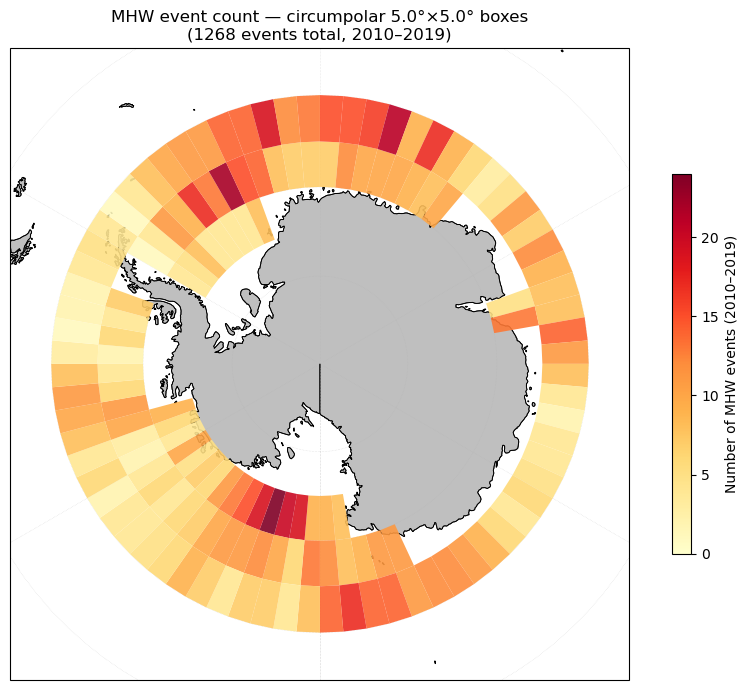

In [13]:
# ── 11a. Event count map ──────────────────────────────────────────────────────
fig = plt.figure(figsize=(9, 7))
ax  = plt.axes(projection=ccrs.SouthPolarStereo())
ax.set_extent([-180, 180, -90, -55], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='0.75', edgecolor='k', linewidth=0.5, zorder=2)
ax.coastlines(linewidth=0.7, zorder=3)
ax.gridlines(draw_labels=False, linestyle=':', linewidth=0.4, alpha=0.5)

vmax_ev = np.nanmax(n_events_grid)
norm_ev = mcolors.Normalize(0, vmax_ev)
cmap_ev = plt.cm.YlOrRd

for box in valid_boxes:
    li, loi = box_to_idx(box)
    n = n_events_grid[li, loi]
    if np.isnan(n):
        continue
    lon0  = box['lon_geo_min'] if box['lon_geo_min'] <= 180 else box['lon_geo_min'] - 360
    color = cmap_ev(norm_ev(n))
    ax.add_patch(Rectangle(
        (lon0, box['lat_min']), BOX_DEG, BOX_DEG,
        facecolor=color, edgecolor='none',
        alpha=0.9, transform=ccrs.PlateCarree(), zorder=4,
    ))

sm = plt.cm.ScalarMappable(cmap=cmap_ev, norm=norm_ev)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Number of MHW events (2010–2019)',
             shrink=0.6, pad=0.05)
ax.set_title(
    f'MHW event count — circumpolar {BOX_DEG}°×{BOX_DEG}° boxes\n'
    f'({total_events} events total, 2010–2019)',
    fontsize=12,
)
plt.tight_layout()

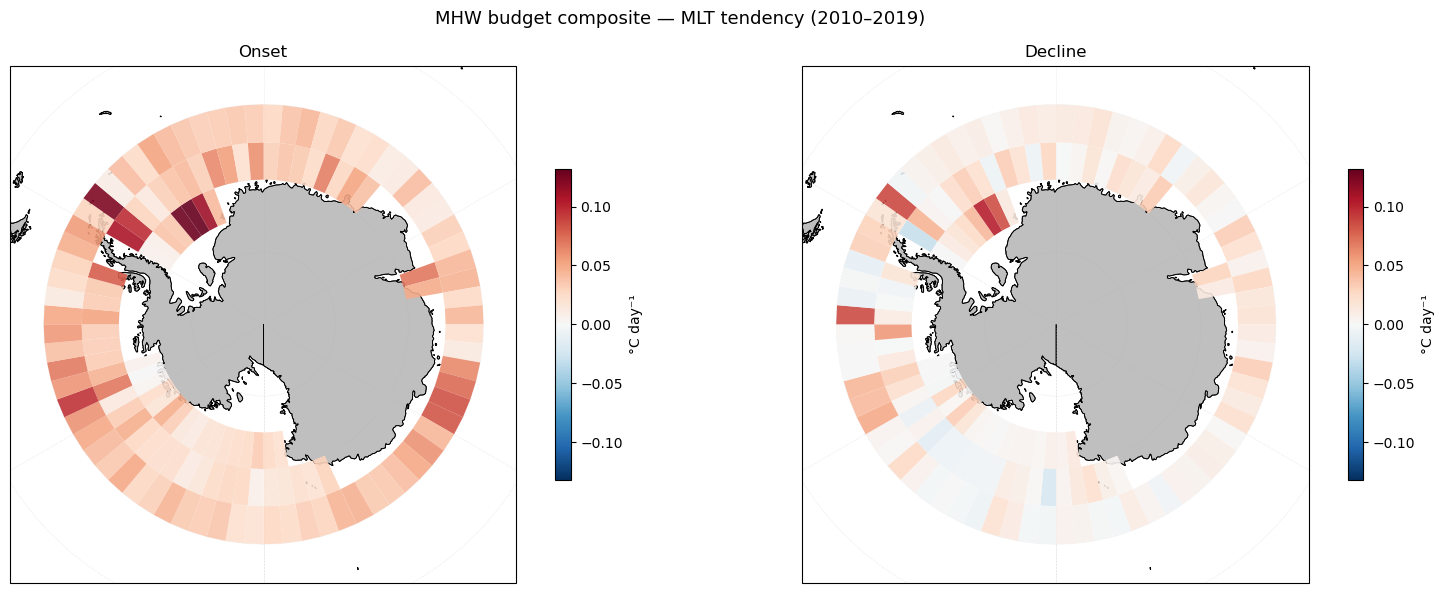

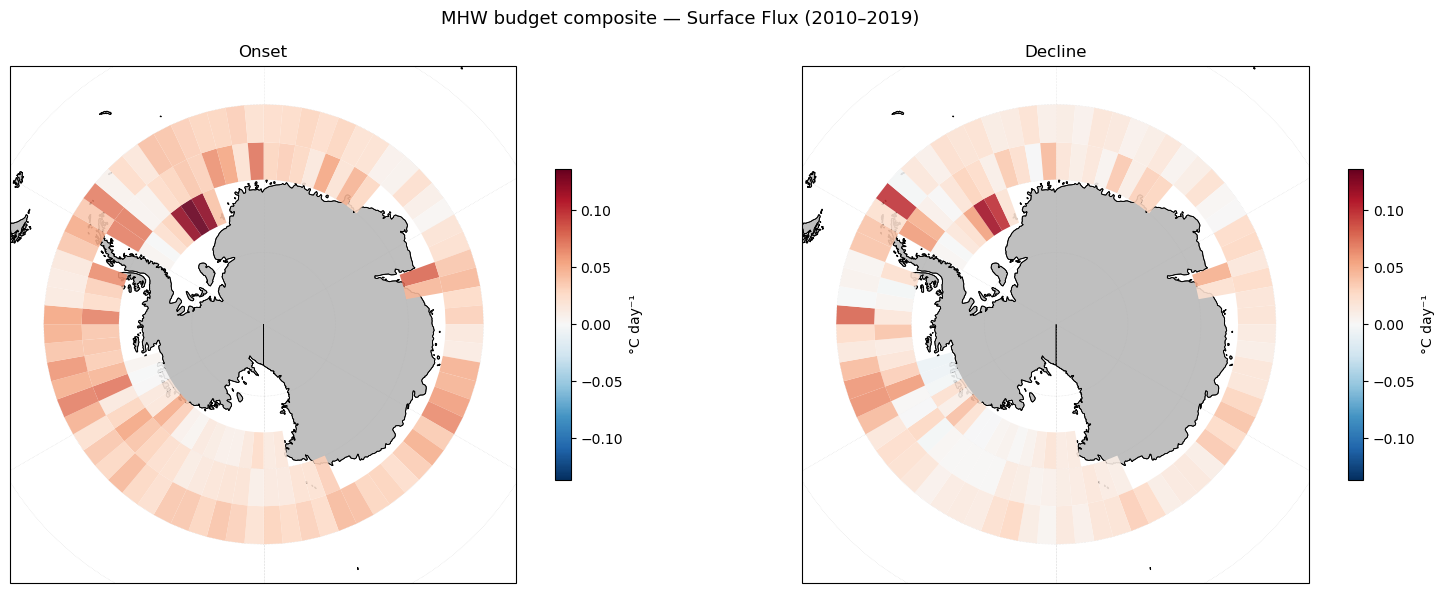

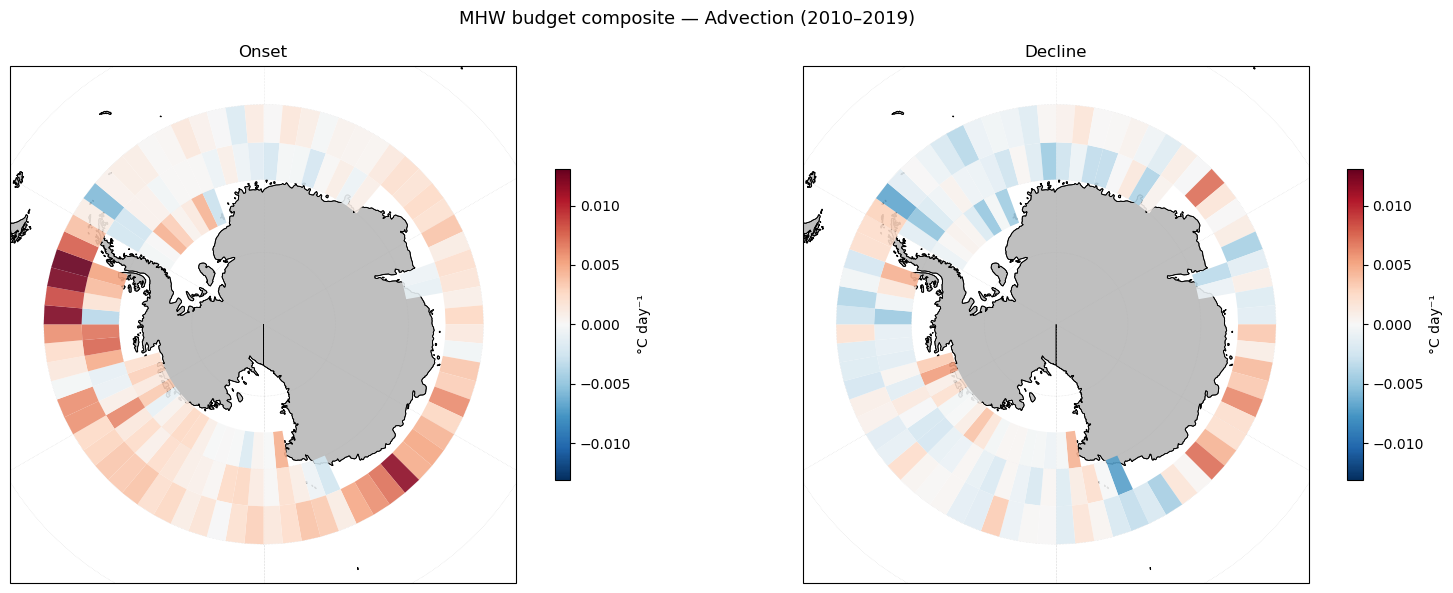

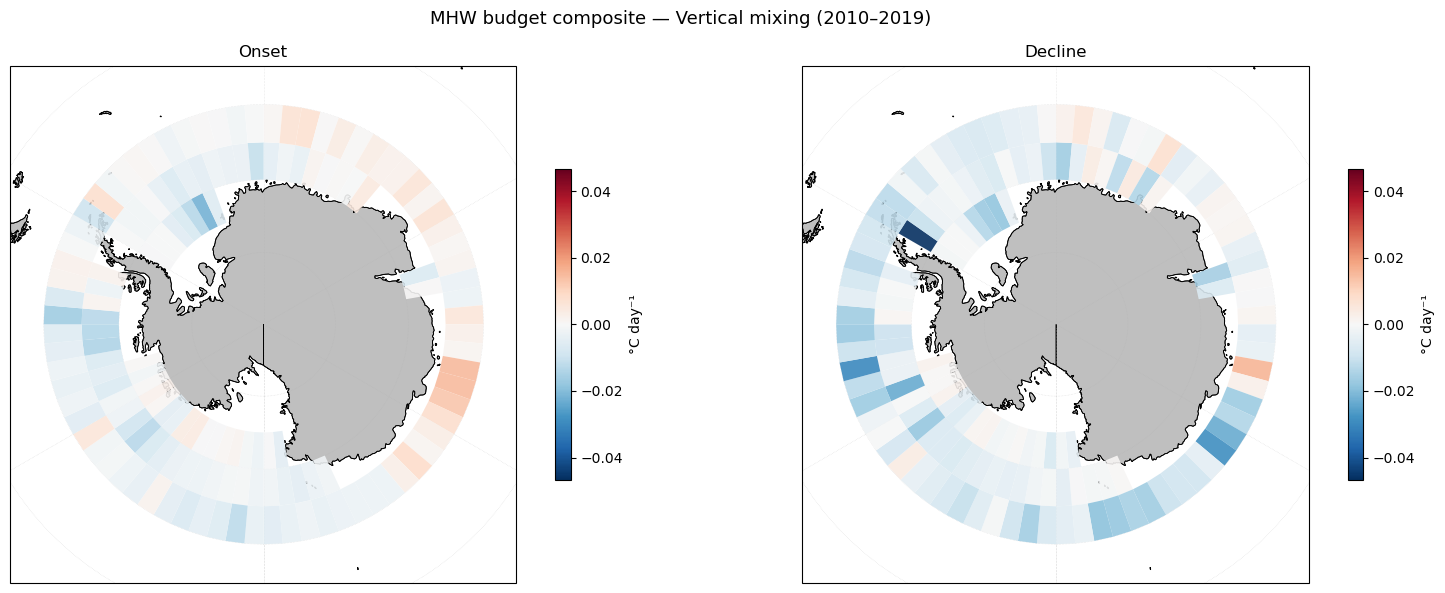

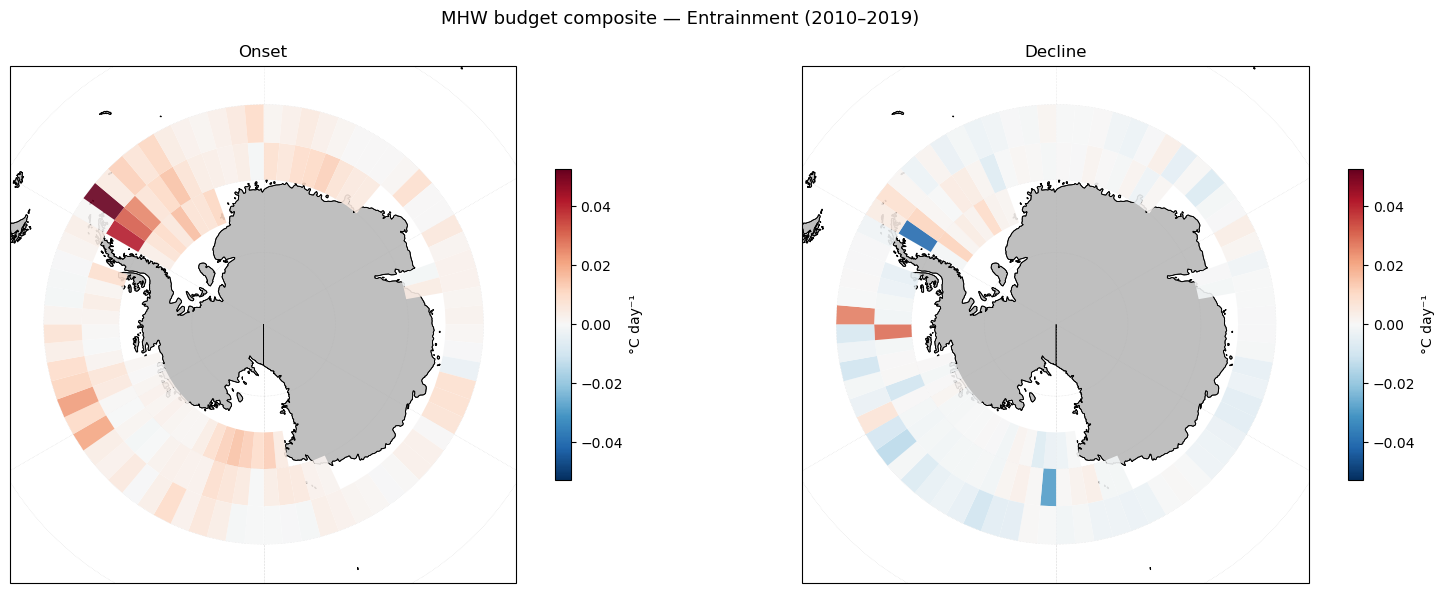

In [14]:
# ── 11b. Onset and decline composite maps — one figure per budget term ─────────
for term in BUDGET_TERMS:
    mat_on = onset_grids[term]
    mat_de = decline_grids[term]
    vmax_t = np.nanmax(np.abs([mat_on, mat_de]))
    if vmax_t == 0 or np.isnan(vmax_t):
        continue
    norm_t = mcolors.TwoSlopeNorm(vcenter=0, vmin=-vmax_t, vmax=vmax_t)

    fig, axes = plt.subplots(
        1, 2, figsize=(16, 6),
        subplot_kw={'projection': ccrs.SouthPolarStereo()},
    )
    for ax, mat, phase in zip(axes, [mat_on, mat_de], ['Onset', 'Decline']):
        ax.set_extent([-180, 180, -90, -55], crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.LAND, facecolor='0.75', edgecolor='k',
                       linewidth=0.5, zorder=2)
        ax.coastlines(linewidth=0.7, zorder=3)
        ax.gridlines(draw_labels=False, linestyle=':', linewidth=0.4, alpha=0.5)

        for box in valid_boxes:
            li, loi = box_to_idx(box)
            v = mat[li, loi]
            if np.isnan(v):
                continue
            lon0  = box['lon_geo_min'] if box['lon_geo_min'] <= 180 else box['lon_geo_min'] - 360
            color = plt.cm.RdBu_r(norm_t(v))
            ax.add_patch(Rectangle(
                (lon0, box['lat_min']), BOX_DEG, BOX_DEG,
                facecolor=color, edgecolor='none',
                alpha=0.9, transform=ccrs.PlateCarree(), zorder=4,
            ))

        sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=norm_t)
        sm.set_array([])
        plt.colorbar(sm, ax=ax, label='°C day⁻¹', shrink=0.6, pad=0.05)
        ax.set_title(phase, fontsize=12)

    fig.suptitle(f'MHW budget composite — {term} (2010–2019)', fontsize=13)
    plt.tight_layout()

## 12. Dominant drivers and event-to-event variability

For each box, three related but distinct questions about which budget term drives onset and decline:

- **Dominant term** — which term has the largest mean |anomaly| across all events in the box (the
  same information as the Section 11b composite maps, reduced to "which term wins").
- **Driver consistency** — for each *individual* event, which term has the largest |anomaly|? This
  map shows the fraction of events in a box where that per-event top term matches the box's most
  common top term. **1.0** = the same term dominates every event. **0.2** (= 1/5 budget terms) =
  the "winning" term is essentially random from event to event — no consistent driver.
- **Driver magnitude variability (CV)** — even when the same term dominates every event, does it
  dominate by a similar amount each time, or does its size vary a lot? This is the coefficient of
  variation (std / |mean|) of the box's dominant term across events. Low = stable driver strength;
  high = same driver, but wildly different strength event to event.

Boxes with fewer than 2 events are left blank in the consistency and CV maps (undefined with a
single event).

In [ ]:
n_terms   = len(BUDGET_TERMS)
term_idx  = {t: i for i, t in enumerate(BUDGET_TERMS)}
EVENT_KEY = ['t_start', 't_peak', 't_end']


def _dominant_term(vals_by_term):
    """Term with the largest |value|; None if all NaN."""
    valid = {t: v for t, v in vals_by_term.items() if not np.isnan(v)}
    return max(valid, key=lambda t: abs(valid[t])) if valid else None


def _event_dominant_terms(df, phase):
    """Per event, the term with the largest |phase| value."""
    idx = df.groupby(EVENT_KEY)[phase].apply(lambda s: s.abs().idxmax())
    return df.loc[idx, 'term'].values


dom_term_onset_grid      = np.full((n_lat, n_lon), np.nan)
dom_term_decline_grid    = np.full((n_lat, n_lon), np.nan)
consistency_onset_grid   = np.full((n_lat, n_lon), np.nan)
consistency_decline_grid = np.full((n_lat, n_lon), np.nan)
cv_onset_grid            = np.full((n_lat, n_lon), np.nan)
cv_decline_grid          = np.full((n_lat, n_lon), np.nan)

for bid, box in zip(box_ids, valid_boxes):
    li, loi = box_to_idx(box)

    dom_on = _dominant_term({t: onset_grids[t][li, loi]   for t in BUDGET_TERMS})
    dom_de = _dominant_term({t: decline_grids[t][li, loi] for t in BUDGET_TERMS})
    if dom_on is not None:
        dom_term_onset_grid[li, loi] = term_idx[dom_on]
    if dom_de is not None:
        dom_term_decline_grid[li, loi] = term_idx[dom_de]

    if len(all_events[bid]) < 2:
        continue
    df = all_df[bid]

    for phase, cons_grid, cv_grid, dom_grid in (
        ('onset',   consistency_onset_grid,   cv_onset_grid,   dom_term_onset_grid),
        ('decline', consistency_decline_grid, cv_decline_grid, dom_term_decline_grid),
    ):
        dom_terms_per_event = _event_dominant_terms(df, phase)
        cons_grid[li, loi] = pd.Series(dom_terms_per_event).value_counts(normalize=True).iloc[0]

        dom_idx = dom_grid[li, loi]
        if not np.isnan(dom_idx):
            vals = df.loc[df.term == BUDGET_TERMS[int(dom_idx)], phase]
            if vals.mean() != 0:
                cv_grid[li, loi] = vals.std() / abs(vals.mean())

print("Driver dominance / consistency / CV grids computed.")

In [ ]:
cmap_dom = mcolors.ListedColormap(plt.cm.tab10.colors[:n_terms])
norm_dom = mcolors.BoundaryNorm(np.arange(-0.5, n_terms, 1), cmap_dom.N)


def _new_polar_ax(fig, nrows, ncols, index):
    ax = fig.add_subplot(nrows, ncols, index, projection=ccrs.SouthPolarStereo())
    ax.set_extent([-180, 180, -90, -55], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='0.75', edgecolor='k', linewidth=0.5, zorder=2)
    ax.coastlines(linewidth=0.7, zorder=3)
    ax.gridlines(draw_labels=False, linestyle=':', linewidth=0.4, alpha=0.5)
    return ax


def _draw_boxes(ax, grid, cmap, norm):
    for box in valid_boxes:
        li, loi = box_to_idx(box)
        v = grid[li, loi]
        if np.isnan(v):
            continue
        lon0 = box['lon_geo_min'] if box['lon_geo_min'] <= 180 else box['lon_geo_min'] - 360
        ax.add_patch(Rectangle(
            (lon0, box['lat_min']), BOX_DEG, BOX_DEG,
            facecolor=cmap(norm(v)), edgecolor='none',
            alpha=0.9, transform=ccrs.PlateCarree(), zorder=4,
        ))


fig = plt.figure(figsize=(15, 7))
ax1 = _new_polar_ax(fig, 1, 2, 1)
ax2 = _new_polar_ax(fig, 1, 2, 2)
_draw_boxes(ax1, dom_term_onset_grid, cmap_dom, norm_dom)
_draw_boxes(ax2, dom_term_decline_grid, cmap_dom, norm_dom)
ax1.set_title('Onset', fontsize=12)
ax2.set_title('Decline', fontsize=12)

handles = [Rectangle((0, 0), 1, 1, facecolor=cmap_dom(i)) for i in range(n_terms)]
fig.legend(handles, BUDGET_TERMS, loc='lower center', ncol=n_terms, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Dominant budget term — largest mean |anomaly| across events', fontsize=13, y=1.02)
plt.tight_layout()

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12),
                         subplot_kw={'projection': ccrs.SouthPolarStereo()})

cmap_cons = plt.cm.viridis
norm_cons = mcolors.Normalize(0.0, 1.0)

cv_vmax = np.nanmax([cv_onset_grid, cv_decline_grid])
cmap_cv = plt.cm.magma_r
norm_cv = mcolors.Normalize(0.0, cv_vmax)

for ax in axes.flat:
    ax.set_extent([-180, 180, -90, -55], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='0.75', edgecolor='k', linewidth=0.5, zorder=2)
    ax.coastlines(linewidth=0.7, zorder=3)
    ax.gridlines(draw_labels=False, linestyle=':', linewidth=0.4, alpha=0.5)

_draw_boxes(axes[0, 0], consistency_onset_grid,   cmap_cons, norm_cons)
_draw_boxes(axes[0, 1], consistency_decline_grid, cmap_cons, norm_cons)
_draw_boxes(axes[1, 0], cv_onset_grid,   cmap_cv, norm_cv)
_draw_boxes(axes[1, 1], cv_decline_grid, cmap_cv, norm_cv)

axes[0, 0].set_title('Onset — driver consistency', fontsize=11)
axes[0, 1].set_title('Decline — driver consistency', fontsize=11)
axes[1, 0].set_title('Onset — driver magnitude CV', fontsize=11)
axes[1, 1].set_title('Decline — driver magnitude CV', fontsize=11)

plt.colorbar(plt.cm.ScalarMappable(cmap=cmap_cons, norm=norm_cons),
             ax=axes[0, :], label='Fraction of events with same top term', shrink=0.7, pad=0.05)
plt.colorbar(plt.cm.ScalarMappable(cmap=cmap_cv, norm=norm_cv),
             ax=axes[1, :], label='CV of dominant term (std / |mean|)', shrink=0.7, pad=0.05)

fig.suptitle('Driver consistency and magnitude variability across events\n'
             '(boxes with <2 events left blank)', fontsize=13)

## 13. Event duration and intensity

For each box, summary statistics of MHW event characteristics across 2010–2019:

- **Duration** — inclusive day count from `t_start` to `t_end` for each event.
- **Intensity** — temperature anomaly at the event peak, relative to the daily climatology
  (`temp − climatology` at `t_peak`). Note `t_peak` itself is chosen during event detection as
  the day of maximum exceedance *above the 90th-percentile threshold*, not above the
  climatology — intensity here reports the climatology-relative anomaly on that same day, which
  is the standard Hobday et al. (2016) intensity metric.

Mean shows the typical event in each box; std shows how much duration/intensity varies event to
event within that box. Boxes with a single event show std = 0 (not a meaningful spread) rather
than blank.

In [ ]:
duration_mean_grid  = np.full((n_lat, n_lon), np.nan)
duration_std_grid   = np.full((n_lat, n_lon), np.nan)
intensity_mean_grid = np.full((n_lat, n_lon), np.nan)
intensity_std_grid  = np.full((n_lat, n_lon), np.nan)

for bid, box in zip(box_ids, valid_boxes):
    events = all_events[bid]
    if not events:
        continue
    li, loi = box_to_idx(box)

    peak_times = [ev['t_peak'] for ev in events]
    durations  = np.array([
        (pd.Timestamp(ev['t_end']) - pd.Timestamp(ev['t_start'])).days + 1 for ev in events
    ])

    temp_vals    = mlt_all[bid]
    clim_mean    = clim_all[bid]
    doy_peak     = np.clip(pd.DatetimeIndex(peak_times).dayofyear.to_numpy(), None, 365)
    temp_at_peak = temp_vals.sel(time=peak_times).values
    clim_at_peak = clim_mean.sel(dayofyear=doy_peak).values
    intensities  = temp_at_peak - clim_at_peak

    duration_mean_grid[li, loi]  = durations.mean()
    duration_std_grid[li, loi]   = durations.std()
    intensity_mean_grid[li, loi] = intensities.mean()
    intensity_std_grid[li, loi]  = intensities.std()

print("Duration / intensity grids computed.")

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12),
                         subplot_kw={'projection': ccrs.SouthPolarStereo()})

for ax in axes.flat:
    ax.set_extent([-180, 180, -90, -55], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='0.75', edgecolor='k', linewidth=0.5, zorder=2)
    ax.coastlines(linewidth=0.7, zorder=3)
    ax.gridlines(draw_labels=False, linestyle=':', linewidth=0.4, alpha=0.5)

panels = [
    (axes[0, 0], duration_mean_grid,  'Mean duration (days)'),
    (axes[0, 1], duration_std_grid,   'Std duration (days)'),
    (axes[1, 0], intensity_mean_grid, 'Mean peak intensity (°C)'),
    (axes[1, 1], intensity_std_grid,  'Std peak intensity (°C)'),
]

for ax, grid, label in panels:
    vmax = np.nanmax(grid)
    norm = mcolors.Normalize(0, vmax) if vmax > 0 else mcolors.Normalize(0, 1)
    _draw_boxes(ax, grid, plt.cm.YlOrRd, norm)
    ax.set_title(label, fontsize=11)
    plt.colorbar(plt.cm.ScalarMappable(cmap=plt.cm.YlOrRd, norm=norm), ax=ax, shrink=0.7, pad=0.05)

fig.suptitle('MHW event duration and intensity — mean and std across events (2010–2019)',
             fontsize=13)
plt.tight_layout()